In [1]:
!pip install rasterio segmentation-models-pytorch captum matplotlib

import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

from google.colab import drive
drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Mounted at /content/drive
Using device: cuda


In [2]:
import rasterio

def read_tif(path):
    with rasterio.open(path) as src:
        arr = src.read()  # (bands, H, W)
    return arr.astype(np.float32)

# Paths
before_path  = "/content/drive/MyDrive/CEMS/EMSN194/s1_before_flood/000000_s1_before_flood.tif"
during_path  = "/content/drive/MyDrive/CEMS/EMSN194/s1_during_flood/000000_s1_during_flood.tif"
terrain_path = "/content/drive/MyDrive/CEMS/EMSN194/terrain/000000_terrain.tif"
lulc_path    = "/content/drive/MyDrive/CEMS/EMSN194/LULC/000000_LULC.tif"

# Read
before  = read_tif(before_path)    # e.g. (2, H, W)
during  = read_tif(during_path)    # e.g. (2, H, W)
terrain = read_tif(terrain_path)   # e.g. (1, H, W)
lulc    = read_tif(lulc_path)      # e.g. (1, H, W)

# Stack along channel dim
stacked = np.concatenate([before, during, terrain, lulc], axis=0)  # (C, H, W)
print("Stacked shape:", stacked.shape)


Stacked shape: (11, 512, 512)


In [3]:
# Copy & normalize per channel (z-score)
x = stacked.astype(np.float32)  # (C, H, W)

for c in range(x.shape[0]):
    m = np.nanmean(x[c])
    s = np.nanstd(x[c]) + 1e-6
    x[c] = (x[c] - m) / s

x_norm = x  # (C, H, W)

# Build input tensor (N, C, H, W)
input_tensor = torch.from_numpy(x_norm).unsqueeze(0).to(device)
print("Input tensor shape:", input_tensor.shape)


Input tensor shape: torch.Size([1, 11, 512, 512])


In [5]:
from segmentation_models_pytorch import Unet

in_channels = x_norm.shape[0]  # should be 11
print("in_channels:", in_channels)

model = Unet(
    encoder_name="resnet50",
    encoder_weights=None,          # <-- your choice, consistent with training
    in_channels=in_channels,       # 11 channels
    classes=1,
    decoder_use_batchnorm=True,
    decoder_block_type="transpose",
).to(device)

state_path = "/content/drive/MyDrive/DL_work/model.pth"
state = torch.load(state_path, map_location=device)
model.load_state_dict(state)
model.eval()

print("Model loaded and set to eval().")


in_channels: 11
Model loaded and set to eval().


In [6]:
with torch.no_grad():
    pred = model(input_tensor)  # (1, 1, H, W)
print("Prediction shape:", pred.shape)


Prediction shape: torch.Size([1, 1, 512, 512])


In [7]:
def saliency_map(model, img):
    img = img.clone().detach().to(device)
    img.requires_grad_(True)

    out = model(img)      # (N, 1, H, W)
    out.sum().backward()

    sal = img.grad.abs().squeeze(0).detach().cpu()  # (C, H, W)
    return sal.sum(0)  # (H, W) – summed over channels

sal_map = saliency_map(model, input_tensor)
print("Saliency map shape:", sal_map.shape)


Saliency map shape: torch.Size([512, 512])


In [8]:
class GradCAM:
    def __init__(self, model, layer):
        self.model = model
        self.activations = None
        self.gradients = None

        def fwd_hook(module, inp, out):
            self.activations = out

        def bwd_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        layer.register_forward_hook(fwd_hook)
        layer.register_full_backward_hook(bwd_hook)

    def __call__(self, img):
        img = img.clone().detach().to(device)
        img.requires_grad_(True)

        out = self.model(img)     # (N, 1, H, W)
        out.sum().backward()

        grads = self.gradients        # (N, C_l, H_l, W_l)
        acts  = self.activations      # (N, C_l, H_l, W_l)

        w = grads.mean(dim=(2, 3), keepdim=True)         # (N, C_l, 1, 1)
        cam = (w * acts).sum(dim=1, keepdim=True)        # (N, 1, H_l, W_l)
        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=img.shape[2:],    # upsample to input size
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze().detach().cpu()  # (H, W)
        return cam

# last block of encoder.layer4
target_layer = model.encoder.layer4[-1]
gradcam = GradCAM(model, target_layer)

cam_map = gradcam(input_tensor)
print("GradCAM map shape:", cam_map.shape)


GradCAM map shape: torch.Size([512, 512])


In [9]:
from captum.attr import IntegratedGradients
import torch.nn as nn

# Move model to CPU for IG to avoid GPU OOM and match Captum expectation
model_cpu = model.to('cpu').eval()

# Build CPU input directly from numpy
input_tensor_cpu = torch.from_numpy(x_norm).unsqueeze(0)  # (1, C, H, W)

class SegmentationWrapper(nn.Module):
    """
    Wrap segmentation model to return a scalar per image
    by averaging the output mask.
    """
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, inp):
        out = self.base_model(inp)      # (N, 1, H, W)
        out = out.mean(dim=(2, 3))      # (N, 1) scalar per sample
        return out

wrapped_model = SegmentationWrapper(model_cpu)
ig = IntegratedGradients(wrapped_model)

baseline = torch.zeros_like(input_tensor_cpu)

attr = ig.attribute(
    input_tensor_cpu,
    baselines=baseline,
    target=0,   # only "class" index
    n_steps=5,
)

# attr: (1, C, H, W)
ig_map = attr.squeeze(0).abs().sum(0).detach().numpy()  # (H, W)

print("IG map shape:", ig_map.shape)

# Move back to GPU for any further stuff
model = model.to(device).eval()


IG map shape: (512, 512)


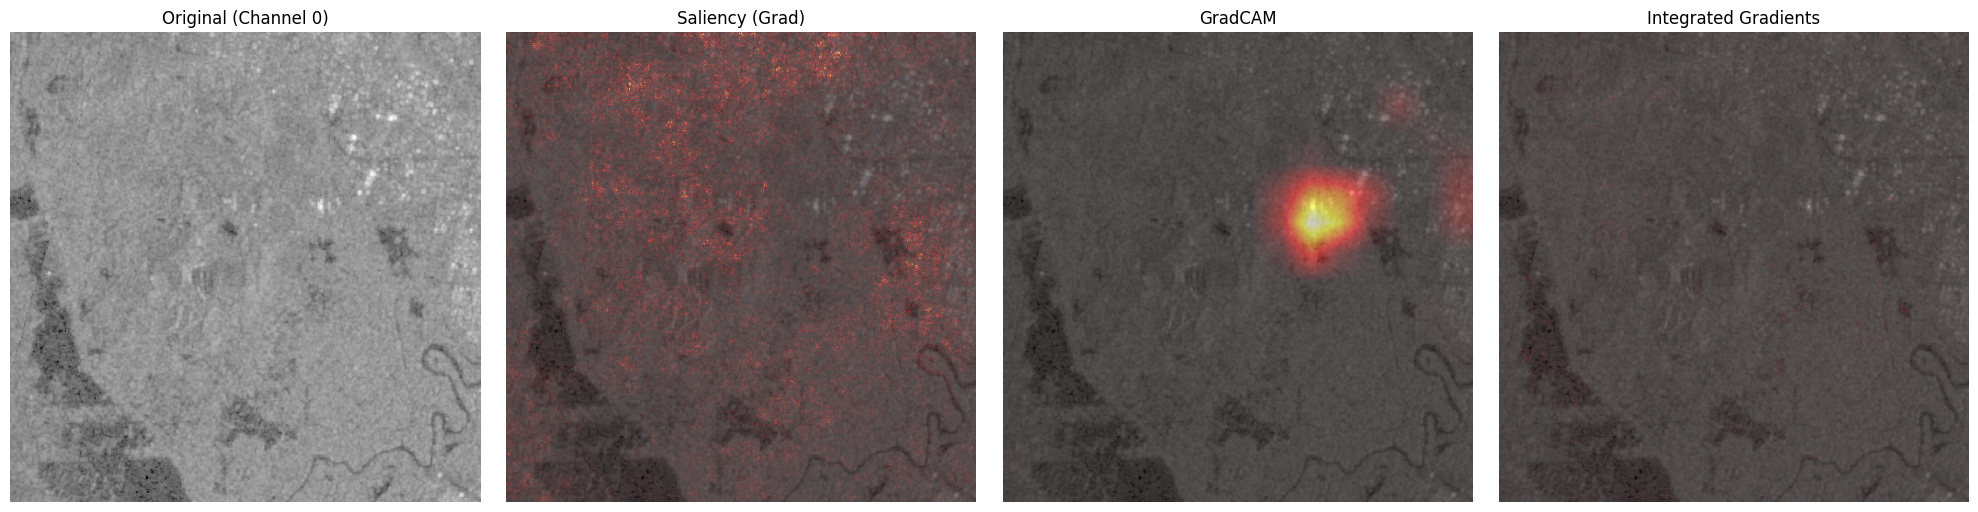

In [ ]:

orig_image = x_norm[0]  # (H, W)

saliency_np = sal_map.numpy()
gradcam_np = cam_map.numpy()
ig_np = ig_map 

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

axs[0].imshow(orig_image, cmap='gray')
axs[0].set_title("Original (Channel 0)")
axs[0].axis('off')

axs[1].imshow(orig_image, cmap='gray')
axs[1].imshow(saliency_np, cmap='hot', alpha=0.5)
axs[1].set_title("Saliency (Grad)")
axs[1].axis('off')

axs[2].imshow(orig_image, cmap='gray')
axs[2].imshow(gradcam_np, cmap='hot', alpha=0.5)
axs[2].set_title("GradCAM")
axs[2].axis('off')

axs[3].imshow(orig_image, cmap='gray')
axs[3].imshow(ig_np, cmap='hot', alpha=0.5)
axs[3].set_title("Integrated Gradients")
axs[3].axis('off')

plt.tight_layout()
plt.show()
